In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [2]:
# a = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\test\ana_0.600_0.300.parquet")
# s = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\test\sim_0.600_0.300.parquet")
a = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\ana\ana_0.096_0.096.parquet")
s = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.096_0.096.parquet")

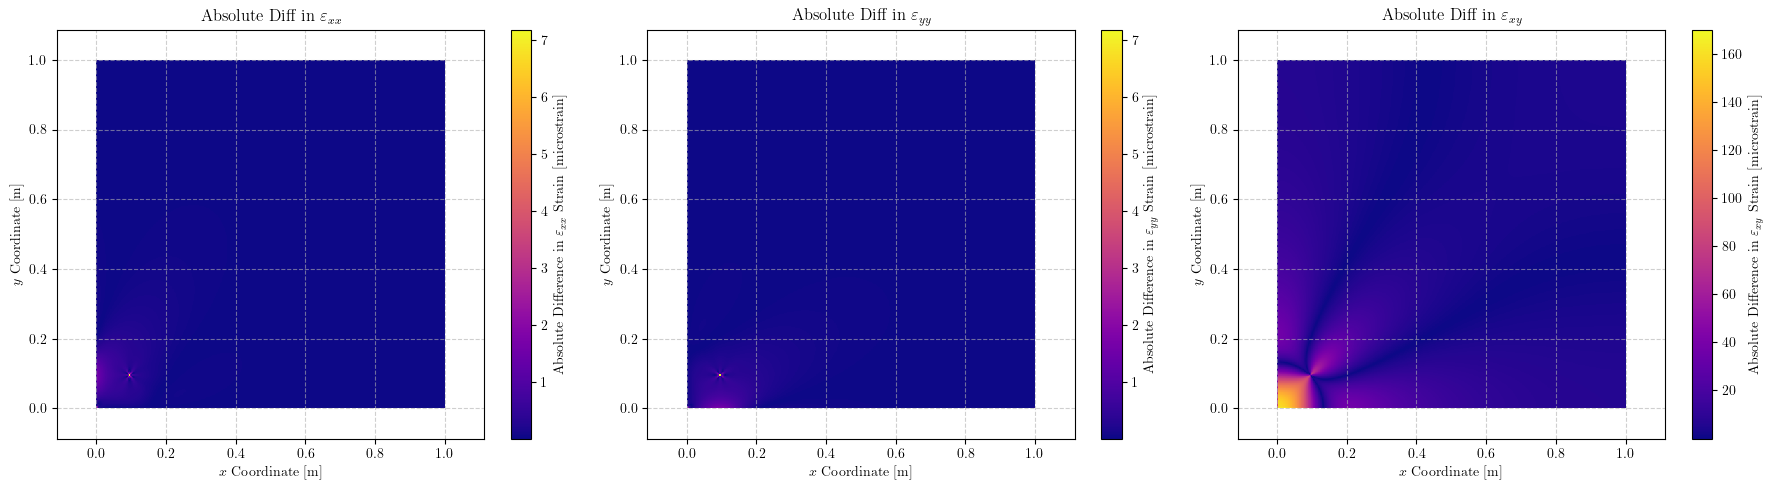

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EXX': abs((s['EXX'].values - a['EXX'].values)),
    'EYY': abs((s['EYY'].values - a['EYY'].values)),
    'EXY': abs((s['EXY'].values - a['EXY'].values)),
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EXX', 'EYY', 'EXY']
strain_symbol = [r'$\varepsilon_{xx}$', r'$\varepsilon_{yy}$', r'$\varepsilon_{xy}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy() * 1e6

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"Absolute Difference in {strain_symbol[i]} Strain"+ r" $\left[\mathrm{microstrain}\right]$")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"Absolute Diff in {strain_symbol[i]}")
    ax[i].axis("equal") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

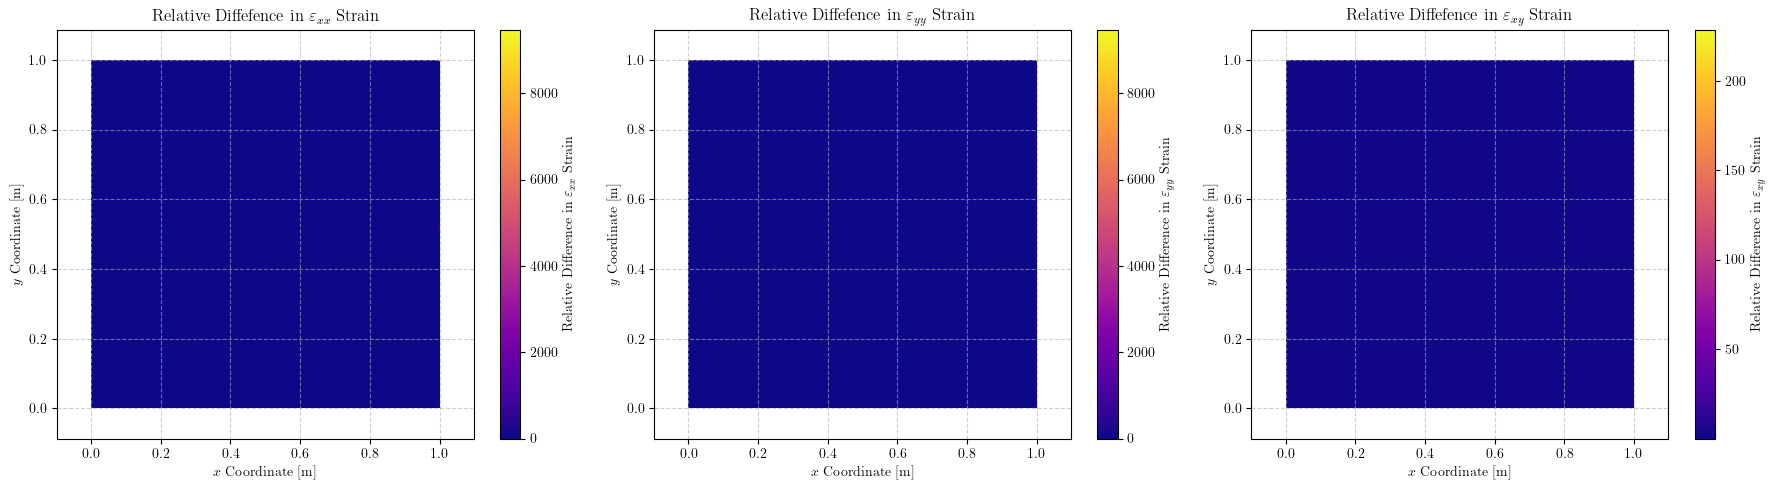

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EXX': abs((s['EXX'].values - a['EXX'].values)/a['EXX'].values),
    'EYY': abs((s['EYY'].values - a['EYY'].values)/a['EYY'].values),
    'EXY': abs((s['EXY'].values - a['EXY'].values)/a['EXY'].values),
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EXX', 'EYY', 'EXY']
strain_symbol = [r'$\varepsilon_{xx}$', r'$\varepsilon_{yy}$', r'$\varepsilon_{xy}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    fig.colorbar(colormesh, ax=ax[i], label=f"Relative Difference in {strain_symbol[i]} Strain")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"Relative Diffefence in {strain_symbol[i]} Strain")
    ax[i].axis("equal") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

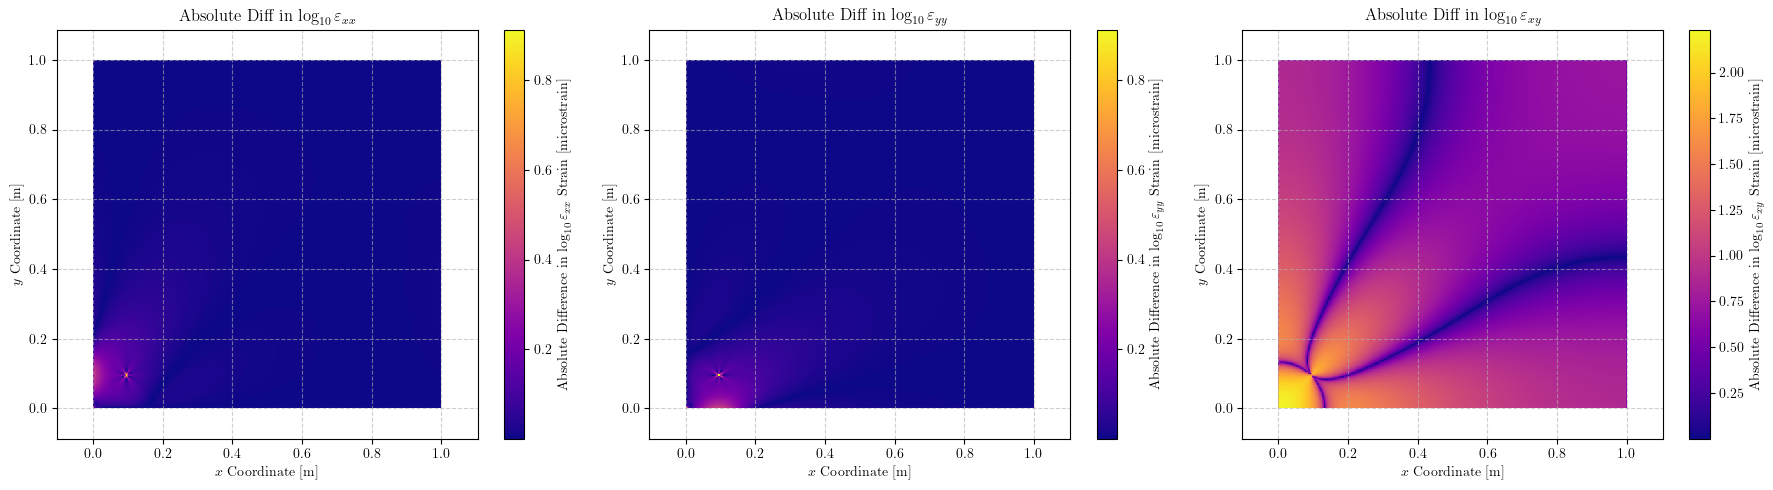

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EXX': abs((s['EXX'].values - a['EXX'].values)),
    'EYY': abs((s['EYY'].values - a['EYY'].values)),
    'EXY': abs((s['EXY'].values - a['EXY'].values)),
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EXX', 'EYY', 'EXY']
strain_symbol = [r'$\log_{10}\varepsilon_{xx}$', r'$\log_{10}\varepsilon_{yy}$', r'$\log_{10}\varepsilon_{xy}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = np.log10(1 + diff_pivot.to_numpy() * 1e6)

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"Absolute Difference in {strain_symbol[i]} Strain"+ r" $\left[\mathrm{microstrain}\right]$")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"Absolute Diff in {strain_symbol[i]}")
    ax[i].axis("equal") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

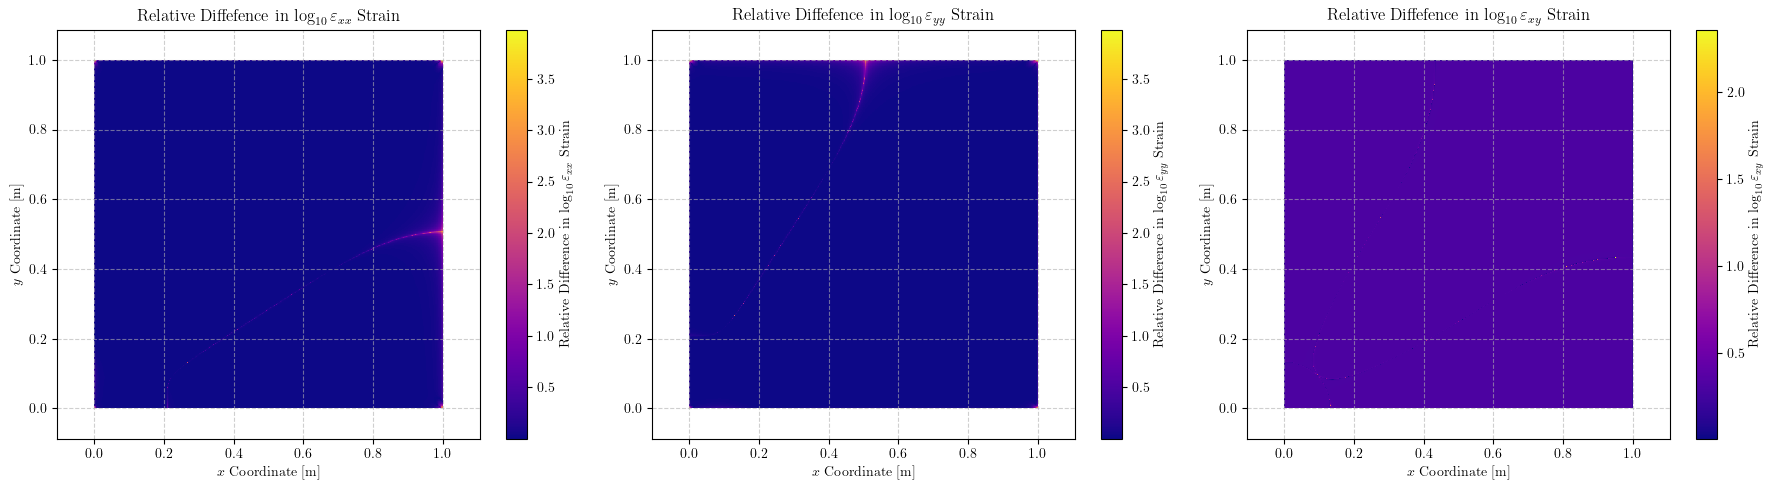

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EXX': abs((s['EXX'].values - a['EXX'].values)/a['EXX'].values),
    'EYY': abs((s['EYY'].values - a['EYY'].values)/a['EYY'].values),
    'EXY': abs((s['EXY'].values - a['EXY'].values)/a['EXY'].values),
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EXX', 'EYY', 'EXY']
strain_symbol = [r'$\log_{10}\varepsilon_{xx}$', r'$\log_{10}\varepsilon_{yy}$', r'$\log_{10}\varepsilon_{xy}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = np.log10(diff_pivot.to_numpy() + 1)

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    fig.colorbar(colormesh, ax=ax[i], label=f"Relative Difference in {strain_symbol[i]} Strain")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"Relative Diffefence in {strain_symbol[i]} Strain")
    ax[i].axis("equal") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()